In [1]:
import sys
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LogNorm
import numpy as np
import sys 
import os
import h5py
# from torreylabtools import helpers
import arepo_package
from astropy import constants as c
from astropy import units as u
from LtU_get_property_notebook import get_particle_property_LTU
from astropy.cosmology import Planck18 as cosmo
from ff_post_processed import post_process_accretion
%matplotlib inline

In [2]:
os.environ["MANPATH"] = "/standard/torrey-group/Share/texlive/2018/texmf-dist/doc/man:" + os.environ.get("MANPATH", "")
os.environ["INFOPATH"] = "/standard/torrey-group/Share/texlive/2018/texmf-dist/doc/info:" + os.environ.get("INFOPATH", "")
os.environ["PATH"] = "/standard/torrey-group/Share/texlive/2018/bin/x86_64-linux:/standard/torrey-group/Share/texlive/2018/texmf-dist:" + os.environ.get("PATH", "")

# Bondi

In [3]:
Filepath = '/project/torrey-group/jkho/LtU_accretion'  # '/project/torrey-group/jkho/LtU_accretion/Low_mass_seeds' 
Box = 'Constrained'
Simpath = 'FF_constrained_AGN_fewseeds_stellar' # 'Bondi_constrained_noAGN_0.1stellar'# 'FF_zoom' # 'Bondi_lowmass_noAGN_fewseeds_z127' # 'Bondi_lowmass_noAGN_z127' 
outputpath = 'output'  # 'Bondi_seed3.19_nofeedback_fewseeds'
basePath = f'{Filepath}/{Box}/{Simpath}/{outputpath}/'
redshifts = np.linspace(19,6,14)
a = 1/(1+redshifts)
i = 0
# BH_QM = get_particle_property_LTU(basePath,'BH_CumEgyInjection_QM',p_type=5, desired_redshift = redshifts[i])
# BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])

In [4]:
redshifts[i]

np.float64(19.0)

In [ ]:
BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])

In [ ]:
Filepath = '/project/torrey-group/jkho/LtU_accretion'  # '/project/torrey-group/jkho/LtU_accretion/Low_mass_seeds' 
Box = 'Constrained'
Simpath = 'FF_constrained_AGN_fewseeds_stellar' # 'Bondi_constrained_noAGN_0.1stellar'# 'FF_zoom' # 'Bondi_lowmass_noAGN_fewseeds_z127' # 'Bondi_lowmass_noAGN_z127' 
outputpath = 'output'  # 'Bondi_seed3.19_nofeedback_fewseeds'
basePath = f'{Filepath}/{Box}/{Simpath}/{outputpath}/'

# header = arepo_package.load_snapshot_header(basePath,6)
# boxsize = header['BoxSize']
h = 0.6774

GAMMA=5./3
GAMMA_MINUS1=GAMMA-1
redshifts = np.linspace(19,6,14)
a = 1/(1+redshifts)
bondi_boost = 100

Masses = []
Mdots = []
SoundSpeed_space = []
Densities = []
Eddington_Rates = []

for i in range(len(redshifts)):
    print(f'Loading redshift {redshifts[i]}')
    
    BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    BH_rhos = get_particle_property_LTU(basePath,'BH_Density',p_type=5, desired_redshift = redshifts[i])
    BH_U = get_particle_property_LTU(basePath,'BH_U',p_type=5, desired_redshift = redshifts[i])
    BH_Eddington = get_particle_property_LTU(basePath,'BH_MdotEddington',p_type=5, desired_redshift = redshifts[i])
    
    most_massive_ind = np.argmax(BH_Mass[0])
    
    SoundSpeed_space.append(np.sqrt(GAMMA * GAMMA_MINUS1 * BH_U[0][most_massive_ind])) # Units: km/s
    Densities.append(BH_rhos[0][most_massive_ind] * (1e10/h)/(a[i]/h)**3) # Units: solar masses/kpc^3
    Masses.append(BH_Mass[0][most_massive_ind]*1e10/h)
    Mdots.append(BH_Mdot[0][most_massive_ind]*1e10/0.978)
    Eddington_Rates.append(BH_Eddington[0][most_massive_ind]*1e10/0.978)

G = c.G.to(u.km**3/(u.Msun*u.s**2)).value
f_env = np.array(SoundSpeed_space)**3/(4*np.pi*G**2*np.array(Densities)/c.kpc.to(u.km).value**3) * (1/u.Gyr.to(u.s)) # Units: Msun*Gyr

specific = []

for i in range(len(redshifts)):

    rate = Masses[i]/f_env[i]
    
    specific.append(rate*bondi_boost)


Loading redshift 19.0


In [ ]:
fig,axs = plt.subplots(3,1,figsize = (8,10),sharex = True)

Accretion_rates = [np.min([np.array(specific_accretion[i]),Eddington_Rates[i]/np.array(Masses[i])]) for i in range(len(redshifts))]

axs[0].scatter(redshifts,np.array(Mdots)/np.array(Masses),label = r'Explicit $\dot{M}/M_{\rm BH}$')
axs[0].scatter(redshifts,Accretion_rates,label = 'Environmentally calculated',s=15,alpha=0.5)
axs[0].set_yscale('log')
axs[0].set_ylabel('Specific Accretion rate [1/Gyr]',size=15)
axs[0].legend()

axs[1].scatter(redshifts,Densities)
axs[1].set_ylabel(r'Gas density $\rm [M_\odot/kpc^3]$',size=15)
axs[1].set_xlabel('Redshift',size=15)

axs[2].scatter(redshifts,SoundSpeed_space,color='green')
axs[2].set_yscale('log')
axs[2].set_ylabel(r'Sound speed [$\rm km/s$]',size=12)

fig.tight_layout()
plt.subplots_adjust(hspace=0)

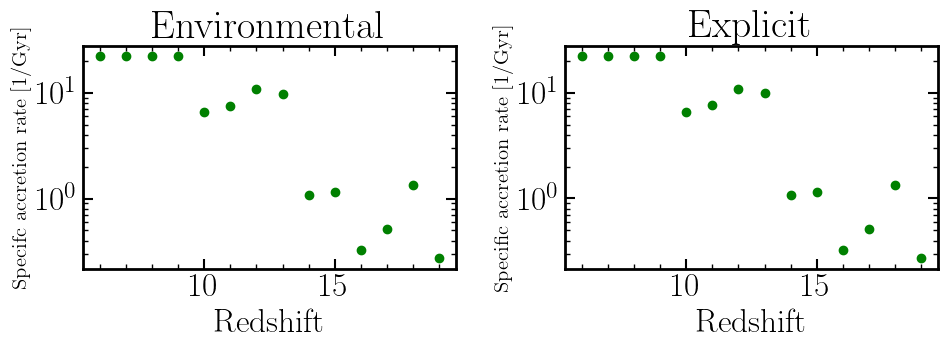

In [8]:
fig,axs = plt.subplots(1,2,figsize=(10,4))

Accretion_rates = [np.min([np.array(specific[i]),Eddington_Rates[i]/np.array(Masses[i])]) for i in range(len(redshifts))]

axs[0].scatter(redshifts,Accretion_rates,label=r'$M_{\rm seed} = 1e5 M_\odot$',color='green')
axs[0].set_yscale('log')
axs[0].set_xlabel('Redshift')
axs[0].set_ylabel(r'Specifc accretion rate [$\rm 1/Gyr$]',size=15)
axs[0].set_title('Environmental')

axs[1].scatter(redshifts,np.array(Mdots)/np.array(Masses),color='green')
axs[1].set_yscale('log')
axs[1].set_xlabel('Redshift')
axs[1].set_ylabel(r'Specific accretion rate [$\rm 1/Gyr$]',size=15)
axs[1].set_title('Explicit')

fig.tight_layout()


In [ ]:
fig,axs = plt.subplots(4,1,figsize=(8,12),sharex = True)

Accretion_rates = [np.min([np.array(specific[i]),Eddington_Rates[i]/np.array(Masses[i])]) for i in range(len(redshifts))]

axs[0].scatter(redshifts,Accretion_rates,label=r'$M_{\rm seed} = 1e5 M_\odot$',color='green')
axs[0].set_yscale('log')
axs[0].set_ylabel(r'Specifc accretion rate [$\rm 1/Gyr$]',size=12)

axs[1].scatter(redshifts,Densities,color='green')
axs[1].set_yscale('log')
axs[1].set_ylabel(r'Densities [$\rm M_\odot/kpc^3$]',size=12)

axs[2].scatter(redshifts,SoundSpeed_space,color='green')
axs[2].set_yscale('log')
axs[2].set_ylabel(r'Sound speed [$\rm km/s$]',size=12)

axs[3].scatter(redshifts,Masses,label=r'$M_{\rm seed} = 1e5 M_\odot$',color='green')
axs[3].set_yscale('log')
axs[3].set_xlabel('Redshift')
axs[3].set_ylabel(r'BH Mass [$\rm M_\odot$]',size=12)

# for ax in axs:
#     ax.set_ylim(1e3,5e15)

# fig.suptitle(f'{Sim_folder}',y=0.95)
# fig.legend(fontsize=10,loc=(0.575,0.75))

fig.tight_layout()
plt.subplots_adjust(hspace=0)

fig.savefig(f'Plots/{Simpath}_components.png')


# Freefall

In [ ]:
Filepath = '/project/torrey-group/jkho/LtU_accretion'  # '/project/torrey-group/jkho/LtU_accretion/Low_mass_seeds' 
Box = 'Low_mass_seeds'
Simpath = 'FF_lowmass_noAGN_fewseeds_z127'# 'FF_zoom' # 'Bondi_lowmass_noAGN_fewseeds_z127' # 'Bondi_lowmass_noAGN_z127' 
outputpath = 'output'  # 'Bondi_seed3.19_nofeedback_fewseeds'
basePath = f'{Filepath}/{Box}/{Simpath}/{outputpath}/'

header = arepo_package.load_snapshot_header(basePath,6)
boxsize = header['BoxSize']
h = 0.6774

GAMMA=5./3
GAMMA_MINUS1=GAMMA-1
redshifts = np.linspace(15,6,10)
a = 1/(1+redshifts)

Masses = []
Mdots = []
SoundSpeed_space = []
Densities = []
# all_accretion = []
accretion_masses = []
accretion_pos = []

for i in range(len(redshifts)):

    print(f"Currently loading redshift {redshifts[i]}")

    d = 0.140 # kpc

    BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    BH_rhos = get_particle_property_LTU(basePath,'BH_Density',p_type=5, desired_redshift = redshifts[i])
    BH_U = get_particle_property_LTU(basePath,'BH_U',p_type=5, desired_redshift = redshifts[i])

    Gas_Mass = get_particle_property_LTU(basePath,'Masses',p_type=0, desired_redshift = redshifts[i])
    Gas_Pos = get_particle_property_LTU(basePath,'Coordinates',p_type=0, desired_redshift = redshifts[i])
    BH_Pos = get_particle_property_LTU(basePath,'Coordinates',p_type=5, desired_redshift = redshifts[i])
    
    most_massive_ind = np.argmax(BH_Mass[0])

    BH_pos = BH_Pos[0][most_massive_ind] * a[i]/h # kpc
    Gas_pos = Gas_Pos[0] * a[i]/h # kpc

    distances = np.linalg.norm(Gas_pos - BH_pos,axis=1)
    Contributing_gas_mask = distances < d # Only gas cells within a distance d of the BH contribute to accretion
    
    # print(f"Minimum distance: {np.min(distances)} kpc")
    
    if np.sum(Gas_Mass[0][Contributing_gas_mask] * 1e10/h) > 0:
        Total_mgas = Gas_Mass[0][Contributing_gas_mask] * 1e10/h # Msun
    else:
        Total_mgas = Gas_Mass[0][np.argmin(distances)] * 1e10/h
    
    SoundSpeed_space.append(np.sqrt(GAMMA * GAMMA_MINUS1 * BH_U[0][most_massive_ind])) # Units: km/s
    Densities.append(BH_rhos[0][most_massive_ind] * (1e10/h)/(a[i]/h)**3) # Units: solar masses/kpc^3
    Masses.append(BH_Mass[0][most_massive_ind]*1e10/h)
    Mdots.append(BH_Mdot[0][most_massive_ind]*1e10/0.978) # Solar masses/Gyr
    # all_accretion.append( (np.sum(BH_QM_Cumgrowth[0])+np.sum(BH_QM_Cumgrowth[0])) * 1e10/h) 
    accretion_masses.append(Total_mgas)
    accretion_pos.append(distances[Contributing_gas_mask])

In [ ]:
G = c.G.to(u.km**3/(u.Msun*u.Gyr**2)).value
light_speed = c.c.to(u.km/u.Gyr).value
kpc2km = u.kpc.to(u.km)
# sec_per_Gyr = u.Gyr.to(u.s)

# modff:
# specific_accretion = sec_per_Gyr*np.array([100*np.sqrt(2) * G/light_speed * np.sum(accretion_masses[i])/(d*kpc2km)**2 for i in range(len(redshifts))])

# ff:
specific_accretion = 0.001*np.sqrt(G/(np.array(Masses)))/(d*kpc2km)**(3/2)*np.array([np.sum(accretion_masses[i]) for i in range(len(redshifts))])


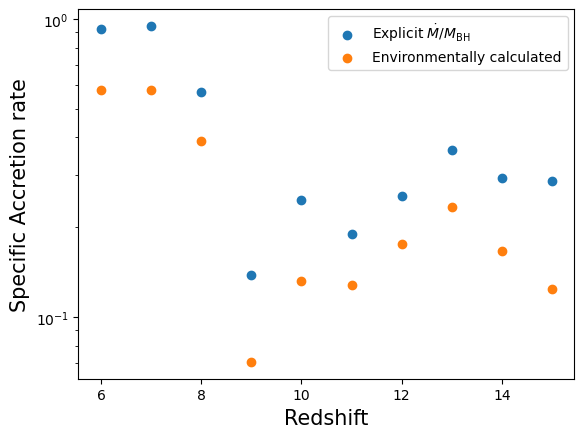

In [23]:
fig,axs = plt.subplots(3,1,figsize = (8,10))

axs[0].scatter(redshifts,np.array(Mdots)/np.array(Masses),label = r'Explicit $\dot{M}/M_{\rm BH}$')
axs[0].scatter(redshifts,specific_accretion,label = 'Environmentally calculated')
axs[0].yscale('log')
axs[0].ylabel('Specific Accretion rate',size=15)
axs[0].xlabel('Redshift',size=15)
axs[0].legend()

densities = np.array([np.sum(accretion_masses[i]) for i in range(len(redshifts))])/((4/3)*np.pi*(d)**3)
axs[1].scatter(redshifts,densities)
axs[1].ylabel(r'Gas density within d $\rm [M_\odot/kpc^3]$',size=15)
axs[1].xlabel('Redshift',size=15)

# plt.savefig(f'{Simpath}/Plots/Specific_accretion_comparison_ff_r140.png')


Text(0.5, 0, 'Redshift')

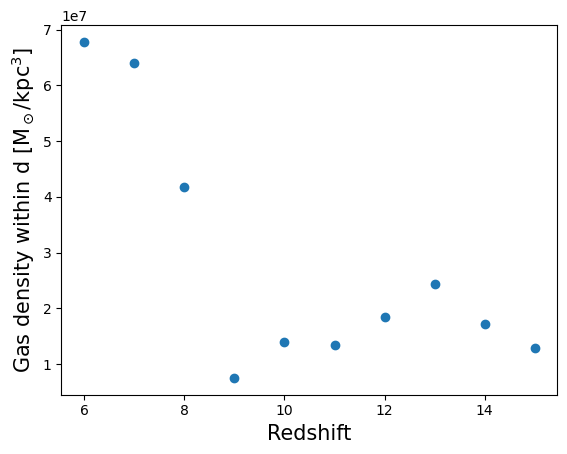

In [36]:
densities = np.array([np.sum(accretion_masses[i]) for i in range(len(redshifts))])/((4/3)*np.pi*(d)**3)
plt.scatter(redshifts,densities)

# plt.yscale('log')
plt.ylabel(r'Gas density within d $\rm [M_\odot/kpc^3]$',size=15)
plt.xlabel('Redshift',size=15)

# modff

In [40]:
Filepath = '/project/torrey-group/jkho/LtU_accretion'  # '/project/torrey-group/jkho/LtU_accretion/Low_mass_seeds' 
Box = 'Low_mass_seeds'
Simpath = 'modFF_lowmass_noAGN_fewseeds_z127'# 'FF_zoom' # 'Bondi_lowmass_noAGN_fewseeds_z127' # 'Bondi_lowmass_noAGN_z127' 
outputpath = 'output'  # 'Bondi_seed3.19_nofeedback_fewseeds'
basePath = f'{Filepath}/{Box}/{Simpath}/{outputpath}/'

header = arepo_package.load_snapshot_header(basePath,6)
boxsize = header['BoxSize']
h = 0.6774

GAMMA=5./3
GAMMA_MINUS1=GAMMA-1
redshifts = np.linspace(15,6,10)
a = 1/(1+redshifts)

Masses = []
Mdots = []
SoundSpeed_space = []
Densities = []
# all_accretion = []
accretion_masses = []
accretion_pos = []

for i in range(len(redshifts)):

    print(f"Currently loading redshift {redshifts[i]}")

    d = 0.140 # kpc

    BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    BH_rhos = get_particle_property_LTU(basePath,'BH_Density',p_type=5, desired_redshift = redshifts[i])
    BH_U = get_particle_property_LTU(basePath,'BH_U',p_type=5, desired_redshift = redshifts[i])

    Gas_Mass = get_particle_property_LTU(basePath,'Masses',p_type=0, desired_redshift = redshifts[i])
    Gas_Pos = get_particle_property_LTU(basePath,'Coordinates',p_type=0, desired_redshift = redshifts[i])
    BH_Pos = get_particle_property_LTU(basePath,'Coordinates',p_type=5, desired_redshift = redshifts[i])
    
    most_massive_ind = np.argmax(BH_Mass[0])

    BH_pos = BH_Pos[0][most_massive_ind] * a[i]/h # kpc
    Gas_pos = Gas_Pos[0] * a[i]/h # kpc

    distances = np.linalg.norm(Gas_pos - BH_pos,axis=1)
    Contributing_gas_mask = distances < d # Only gas cells within a distance d of the BH contribute to accretion
    
    # print(f"Minimum distance: {np.min(distances)} kpc")
    
    if np.sum(Gas_Mass[0][Contributing_gas_mask] * 1e10/h) > 0:
        Total_mgas = Gas_Mass[0][Contributing_gas_mask] * 1e10/h # Msun
    else:
        Total_mgas = Gas_Mass[0][np.argmin(distances)] * 1e10/h
    
    SoundSpeed_space.append(np.sqrt(GAMMA * GAMMA_MINUS1 * BH_U[0][most_massive_ind])) # Units: km/s
    Densities.append(BH_rhos[0][most_massive_ind] * (1e10/h)/(a[i]/h)**3) # Units: solar masses/kpc^3
    Masses.append(BH_Mass[0][most_massive_ind]*1e10/h)
    Mdots.append(BH_Mdot[0][most_massive_ind]*1e10/0.978) # Solar masses/Gyr
    # all_accretion.append( (np.sum(BH_QM_Cumgrowth[0])+np.sum(BH_QM_Cumgrowth[0])) * 1e10/h) 
    accretion_masses.append(Total_mgas)
    accretion_pos.append(distances[Contributing_gas_mask])

Desired redshift:  6
Output redshift:  6.0107573988449
Output snapshot:  19
Currently loading redshift 15.0
Currently loading redshift 14.0
Currently loading redshift 13.0
Currently loading redshift 12.0
Currently loading redshift 11.0
Currently loading redshift 10.0
Currently loading redshift 9.0
Currently loading redshift 8.0
Currently loading redshift 7.0
Currently loading redshift 6.0


In [41]:
G = c.G.to(u.km**3/(u.Msun*u.s**2)).value
light_speed = c.c.to(u.km/u.s).value
kpc2km = u.kpc.to(u.km)
sec_per_Gyr = u.Gyr.to(u.s)

# modff:
specific_accretion = sec_per_Gyr*np.array([100*np.sqrt(2) * G/light_speed * np.sum(accretion_masses[i])/(d*kpc2km)**2 for i in range(len(redshifts))])

# ff:
# specific_accretion = sec_per_Gyr*0.001*np.sqrt(G/(Masses*d**3))*np.array([np.sum(accretion_masses[i]) for i in range(len(redshifts))])


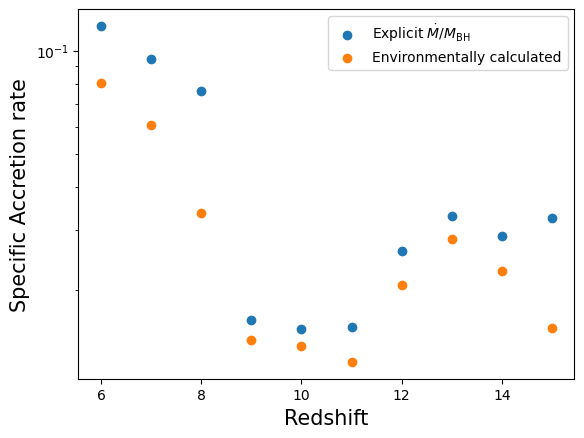

In [45]:
plt.scatter(redshifts,np.array(Mdots)/np.array(Masses),label = r'Explicit $\dot{M}/M_{\rm BH}$')
plt.scatter(redshifts,specific_accretion,label = 'Environmentally calculated')
plt.yscale('log')
plt.ylabel('Specific Accretion rate',size=15)
plt.xlabel('Redshift',size=15)
plt.legend()
plt.savefig(f'Plots/{Simpath}_Specific_accretion_comparison_modff_r140.png')


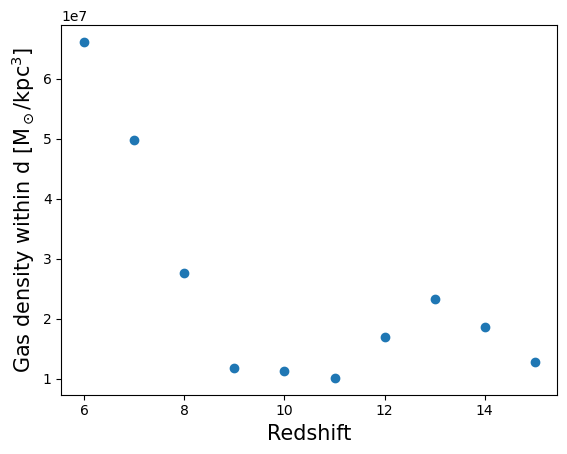

In [46]:
densities = np.array([np.sum(accretion_masses[i]) for i in range(len(redshifts))])/((4/3)*np.pi*(d)**3)
plt.scatter(redshifts,densities)

# plt.yscale('log')
plt.ylabel(r'Gas density within d $\rm [M_\odot/kpc^3]$',size=15)
plt.xlabel('Redshift',size=15)
plt.savefig(f'Plots/{Simpath}_density_modff_r140.png')


# Using script

In [3]:
# basePath = '/project/torrey-group/jkho/LtU_accretion/Constrained/Bondi_constrained_AGN_fewseeds_stellar/output/'
basePath = '/project/torrey-group/jkho/LtU_accretion/Constrained/Alpha_m1.5_constrained_AGN_fewseeds_stellar/output/'

z,mdots_m1_5 = post_process_accretion(basePath,alpha_desired=-1.5)
z,mdots_m1_0 = post_process_accretion(basePath,alpha_desired=-1)
z,mdots_m0_5 = post_process_accretion(basePath,alpha_desired=-0.5)
z,mdots_0_0 = post_process_accretion(basePath,alpha_desired=0)
z,mdots_0_5 = post_process_accretion(basePath,alpha_desired=0.5)

Desired redshift:  6
Output redshift:  7.008044508286467
Output snapshot:  18
Currently loading redshift 15.0
Currently loading redshift 14.0
Currently loading redshift 13.0
Currently loading redshift 12.0
Currently loading redshift 11.0
Currently loading redshift 10.0
Currently loading redshift 9.0
Currently loading redshift 8.0
Currently loading redshift 7.0
Currently loading redshift 6.0
Desired redshift:  6
Output redshift:  7.008044508286467
Output snapshot:  18
Currently loading redshift 15.0
Currently loading redshift 14.0
Currently loading redshift 13.0
Currently loading redshift 12.0
Currently loading redshift 11.0
Currently loading redshift 10.0
Currently loading redshift 9.0
Currently loading redshift 8.0
Currently loading redshift 7.0
Currently loading redshift 6.0
Desired redshift:  6
Output redshift:  7.008044508286467
Output snapshot:  18
Currently loading redshift 15.0
Currently loading redshift 14.0
Currently loading redshift 13.0
Currently loading redshift 12.0
Curren

In [5]:
basePath = '/project/torrey-group/jkho/LtU_accretion/Constrained/Bondi_constrained_AGN_fewseeds_stellar/output/'

h = 0.6774

GAMMA=5./3
GAMMA_MINUS1=GAMMA-1
redshifts= np.linspace(15,6,10)
a = 1/(1+redshifts)
bondi_boost = 100

Mdots = []

for i in range(len(redshifts)):
    print(f'Loading redshift {redshifts[i]}')
    
    BH_Mass = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    
    most_massive_ind = np.argmax(BH_Mass[0])
    
    Mdots.append(BH_Mdot[0][most_massive_ind]*1e10/0.978)

Mdots = np.array(Mdots)

Loading redshift 15.0
Loading redshift 14.0
Loading redshift 13.0
Loading redshift 12.0
Loading redshift 11.0
Loading redshift 10.0
Loading redshift 9.0
Loading redshift 8.0
Loading redshift 7.0
Loading redshift 6.0


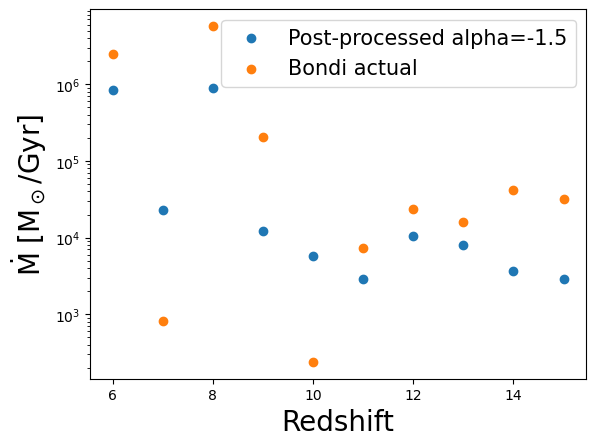

In [11]:
plt.scatter(z,mdots,label = 'Post-processed alpha=-1.5')
plt.scatter(z,Mdots,label = 'Bondi actual')
plt.yscale('log')
plt.xlabel('Redshift',size=20)
plt.ylabel(r'$\rm \dot{M}~[M_\odot/Gyr]$',size=20)
plt.legend(fontsize=15)
plt.savefig('Plots/alpha_m1.5_post.png')

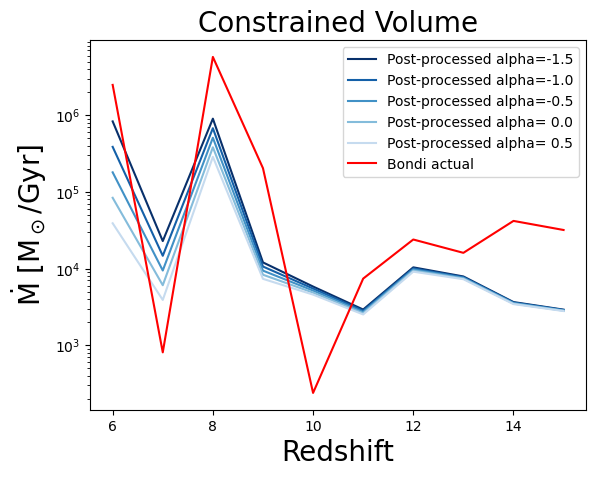

In [21]:
cmap = plt.get_cmap('Blues')
colors = cmap(np.linspace(1, 0.25, 5))

plt.plot(z,mdots_m1_5,label = 'Post-processed alpha=-1.5',color=colors[0])
plt.plot(z,mdots_m1_0,label = 'Post-processed alpha=-1.0',color=colors[1])
plt.plot(z,mdots_m0_5,label = 'Post-processed alpha=-0.5',color=colors[2])
plt.plot(z,mdots_0_0,label = 'Post-processed alpha= 0.0',color=colors[3])
plt.plot(z,mdots_0_5,label = 'Post-processed alpha= 0.5',color=colors[4])
plt.plot(z,Mdots,label = 'Bondi actual',color='red')
plt.yscale('log')
plt.xlabel('Redshift',size=20)
plt.ylabel(r'$\rm \dot{M}~[M_\odot/Gyr]$',size=20)
plt.legend(fontsize=10)
plt.title('Constrained Volume',size=20)
plt.savefig('Plots/alpha_range_post.png')

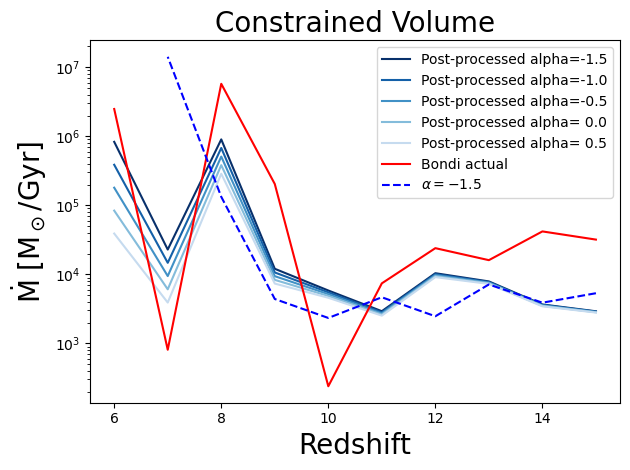

In [16]:
basePath = '/project/torrey-group/jkho/LtU_accretion/Constrained/Alpha_m1.5_constrained_AGN_fewseeds_stellar/output/'
redshifts= np.linspace(15,6,10)
Mdots_m1_5 = []

h = 0.6774
for i in range(len(redshifts)):
    BH_Mass,z = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot,z = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    most_massive_ind = np.argmax(BH_Mass)
    Mdots_m1_5.append(BH_Mdot[most_massive_ind] * 1e10/0.978)
    
cmap = plt.get_cmap('Blues')
colors = cmap(np.linspace(1, 0.25, 5))

plt.plot(redshifts,mdots_m1_5,label = 'Post-processed alpha=-1.5',color=colors[0])
plt.plot(redshifts,mdots_m1_0,label = 'Post-processed alpha=-1.0',color=colors[1])
plt.plot(redshifts,mdots_m0_5,label = 'Post-processed alpha=-0.5',color=colors[2])
plt.plot(redshifts,mdots_0_0,label = 'Post-processed alpha= 0.0',color=colors[3])
plt.plot(redshifts,mdots_0_5,label = 'Post-processed alpha= 0.5',color=colors[4])
plt.plot(redshifts,Mdots,label = 'Bondi actual',color='red')
plt.plot(redshifts[:-1],Mdots_m1_5[:-1],label = r'$\alpha=-1.5$',color='blue',ls='--')
plt.yscale('log')
plt.xlabel('Redshift',size=20)
plt.ylabel(r'$\rm \dot{M}~[M_\odot/Gyr]$',size=20)
plt.legend(fontsize=10)
plt.title('Constrained Volume',size=20)
plt.tight_layout()
plt.savefig('Plots/Alphas/alpha_range_post_compare.png')

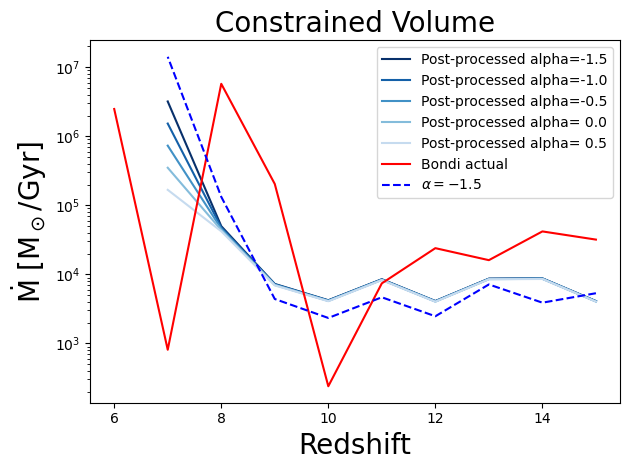

In [7]:
basePath = '/project/torrey-group/jkho/LtU_accretion/Constrained/Alpha_m1.5_constrained_AGN_fewseeds_stellar/output/'
redshifts= np.linspace(15,6,10)
Mdots_m1_5 = []

h = 0.6774
for i in range(len(redshifts)):
    BH_Mass,z = get_particle_property_LTU(basePath,'BH_Mass',p_type=5, desired_redshift = redshifts[i])
    BH_Mdot,z = get_particle_property_LTU(basePath,'BH_Mdot',p_type=5, desired_redshift = redshifts[i])
    most_massive_ind = np.argmax(BH_Mass)
    Mdots_m1_5.append(BH_Mdot[most_massive_ind] * 1e10/0.978)
    
cmap = plt.get_cmap('Blues')
colors = cmap(np.linspace(1, 0.25, 5))

plt.plot(redshifts[:-1],mdots_m1_5[:-1],label = 'Post-processed alpha=-1.5',color=colors[0])
plt.plot(redshifts[:-1],mdots_m1_0[:-1],label = 'Post-processed alpha=-1.0',color=colors[1])
plt.plot(redshifts[:-1],mdots_m0_5[:-1],label = 'Post-processed alpha=-0.5',color=colors[2])
plt.plot(redshifts[:-1],mdots_0_0[:-1],label = 'Post-processed alpha= 0.0',color=colors[3])
plt.plot(redshifts[:-1],mdots_0_5[:-1],label = 'Post-processed alpha= 0.5',color=colors[4])
plt.plot(redshifts,Mdots,label = 'Bondi actual',color='red')
plt.plot(redshifts[:-1],Mdots_m1_5[:-1],label = r'$\alpha=-1.5$',color='blue',ls='--')
plt.yscale('log')
plt.xlabel('Redshift',size=20)
plt.ylabel(r'$\rm \dot{M}~[M_\odot/Gyr]$',size=20)
plt.legend(fontsize=10)
plt.title('Constrained Volume',size=20)
plt.tight_layout()
plt.savefig('Plots/Alphas/alpha_range_post_compare_a2a.png')

In [23]:
alpha_desired = -1.5
m = (2 - (-3)) / (-0.5 - 0)
b = -3
A_pred = 10**(m * alpha_desired + b)
print(np.log10(A_pred))

12.0


### Mseed=1e5

In [14]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed=1e5

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

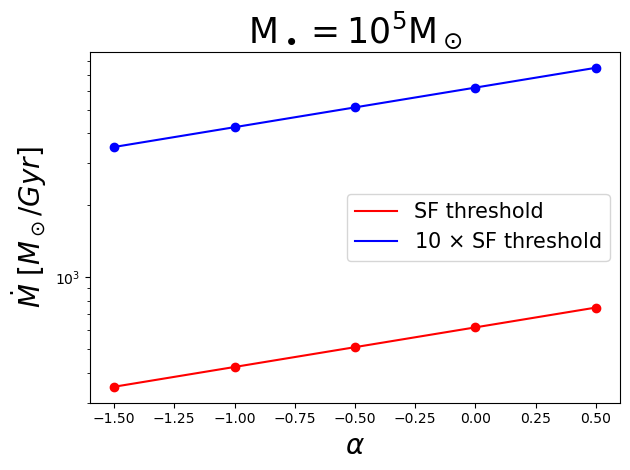

In [15]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^5 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}.png')

### Mseed = 1e7

In [12]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed = 1e7

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

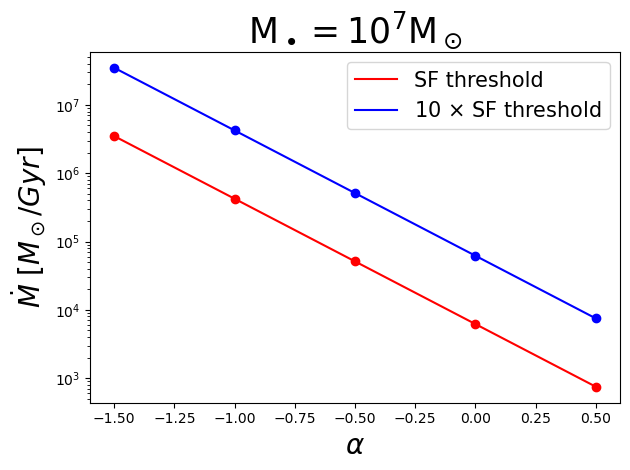

In [13]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^7 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}.png')

### Mseed = 1e3

In [16]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed = 1e3

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

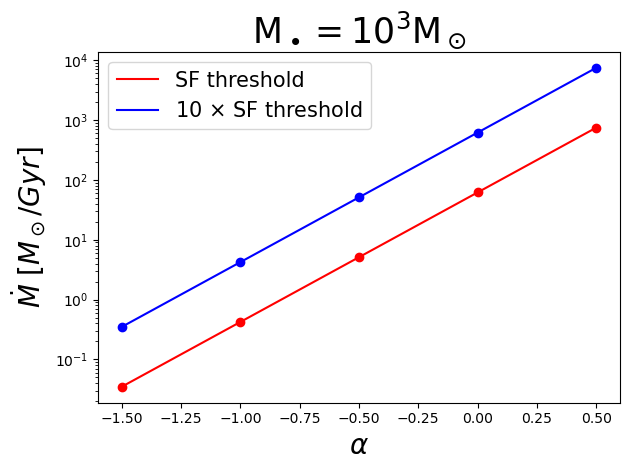

In [18]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^3 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}.png')

# Applying Rainer's method

In [3]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed = 1e7

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

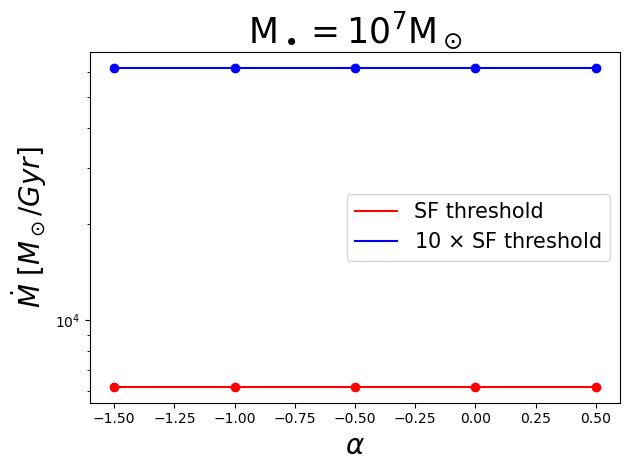

In [4]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^7 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}_Rainer.png')

In [10]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed = 1e5

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

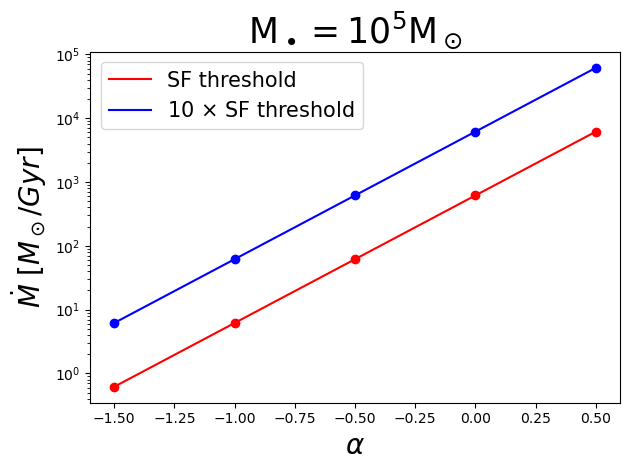

In [11]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^5 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}_Rainer.png')

In [7]:
rho_sf = 4.2e6 # Msun/kpc^3
alphas=np.arange(-1.5,1,0.5)
Mseed = 1e3

z,mdots_m1_5 = post_process_accretion(alpha_desired=alphas[0],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0 = post_process_accretion(alpha_desired=alphas[1],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5 = post_process_accretion(alpha_desired=alphas[2],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0 = post_process_accretion(alpha_desired=alphas[3],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5 = post_process_accretion(alpha_desired=alphas[4],constant_rho = rho_sf,Mseed=Mseed,Rainer = True)
mdots_sf = [mdots_m1_5,mdots_m1_0,mdots_m0_5,mdots_0_0,mdots_0_5]

z,mdots_m1_5_rho10 = post_process_accretion(alpha_desired=alphas[0],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m1_0_rho10 = post_process_accretion(alpha_desired=alphas[1],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_m0_5_rho10 = post_process_accretion(alpha_desired=alphas[2],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_0_rho10 = post_process_accretion(alpha_desired=alphas[3],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
z,mdots_0_5_rho10 = post_process_accretion(alpha_desired=alphas[4],constant_rho = 10*rho_sf,Mseed=Mseed,Rainer = True)
mdots_10sf = [mdots_m1_5_rho10,mdots_m1_0_rho10,mdots_m0_5_rho10,mdots_0_0_rho10,mdots_0_5_rho10]

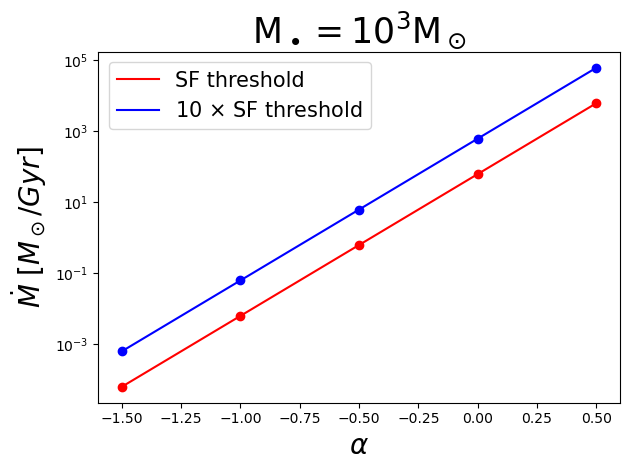

In [9]:
plt.plot(alphas,mdots_sf,label = r'SF threshold',color='red')
plt.plot(alphas,mdots_10sf,label = r'10 $\times$ SF threshold',color='blue')
plt.scatter(alphas,mdots_sf,color='red')
plt.scatter(alphas,mdots_10sf,color='blue')

plt.legend(fontsize=15)
plt.xlabel(r'$\alpha$',size=20)
plt.ylabel(r'$\dot{M}~[M_\odot/Gyr]$',size=20)
plt.yscale('log')
plt.title(r'$\rm M_\bullet = 10^3 M_\odot$',size=25)
plt.tight_layout()
plt.savefig(f'Plots/Alphas/SF_thresh_Me{np.log10(Mseed)}_Rainer.png')